In [41]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
db_path = os.path.join(base_dir, "data", "electricity.db")
conn = sqlite3.connect(db_path)

df = pd.read_sql("""
    SELECT * FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    ORDER BY datetime
""", conn)

print(df.shape)
df.describe()

(52608, 6)


,hour,price_es,year,month,day
count,52608.000000,52602.000000,52608.000000,52608.000000,52608.000000
mean,12.500000,85.173219,2021.500456,6.521898,15.732664
std,6.922252,66.436512,1.708197,3.449019,8.801454
min,1.000000,-2.000000,2019.000000,1.000000,1.000000
25%,6.750000,39.660000,2020.000000,4.000000,8.000000
50%,12.500000,63.095000,2021.500000,7.000000,16.000000
75%,18.250000,117.050000,2023.000000,10.000000,23.000000
max,24.000000,700.000000,2024.000000,12.000000,31.000000


### Average price per day over 6 years

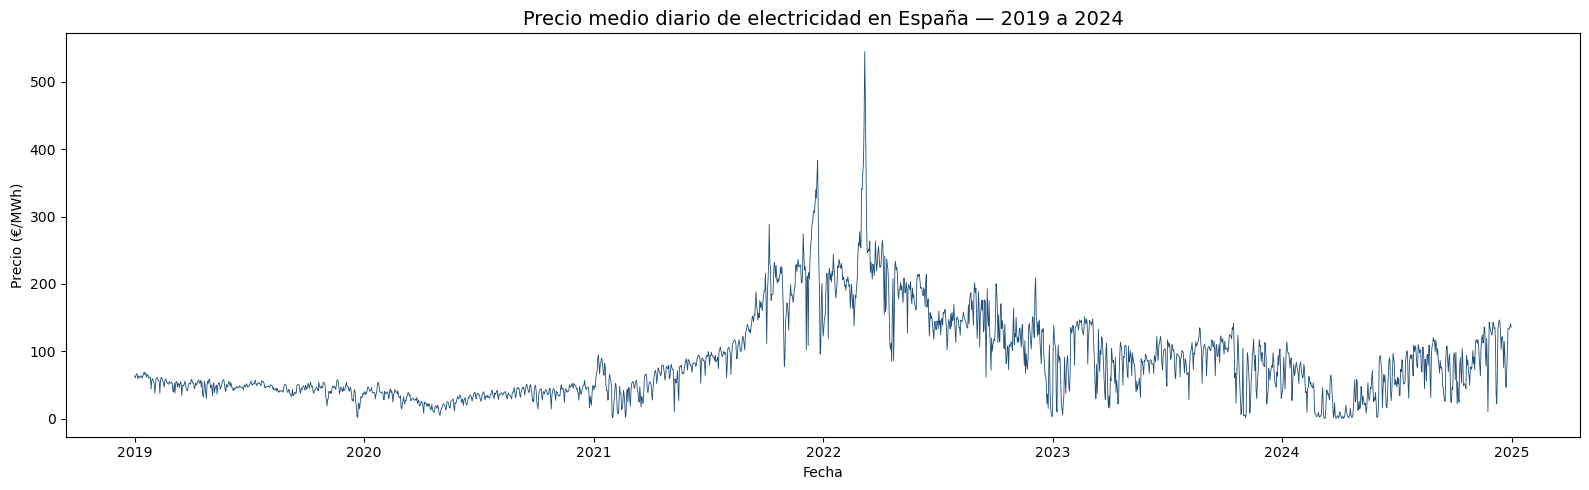

In [42]:
df_daily = pd.read_sql("""
    SELECT year, month, day, AVG(price_es) as avg_price
    FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    GROUP BY year, month, day
    ORDER BY year, month, day
""", conn)

df_daily["date"] = pd.to_datetime(df_daily[["year", "month", "day"]])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_daily["date"], df_daily["avg_price"], linewidth=0.6, color="#1F4E79")
ax.set_title("Precio medio diario de electricidad en España — 2019 a 2024", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (€/MWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig("../outputs/precio_diario_historico.png", dpi=150)
plt.show()

Se aprecia el pico impresionante en el año 2022 debido a la crisis energetica desencadenada tras la invasion en Ucrania. Despues todo se estabiliza mas aunque la produccion pasa a tener mas picos continuos. ¿Es esto el reflejo de las renovables por encima de la constancia del gas? ¿Causa de la excepcion iberica?

### Average price per hour

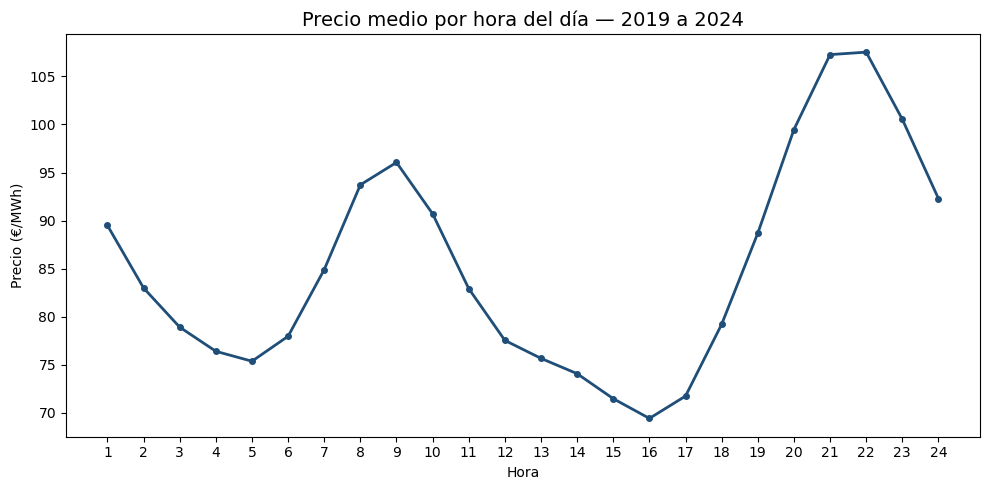

In [43]:
df_hourly = pd.read_sql("""
    SELECT hour, AVG(price_es) as avg_price
    FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    GROUP BY hour
    ORDER BY hour
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_hourly["hour"], df_hourly["avg_price"],
        linewidth=2, color="#1F4E79", marker="o", markersize=4)
ax.set_title("Precio medio por hora del día — 2019 a 2024", fontsize=14)
ax.set_xlabel("Hora")
ax.set_ylabel("Precio (€/MWh)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.savefig("../outputs/precio_por_hora_historico.png", dpi=150)
plt.show()

Un buen pato tipico de las renovables, ¿seria igual antes de la excepcion iberica?

#### Comparacion entre 2019 y 2023. Antes y despues de la guerra en 2022

Tras la guerra en Ucrania en 2022 se puso en marcha el mecanismo de la 'escepcion iberica' por medio del cual el precio del gas se desacopla del precio de la electricidad. Esto conlleva que a partir de entonces las oscilaciones del precio son mas fuertes debido a la fuerte presencia de renovables. Antes de la guerra (incluso con fotovoltaica, eolica e hidraulica) el precio de la electricidad a gas marcaba el precio de mercado y lo hacia mas estable y menos oscilante

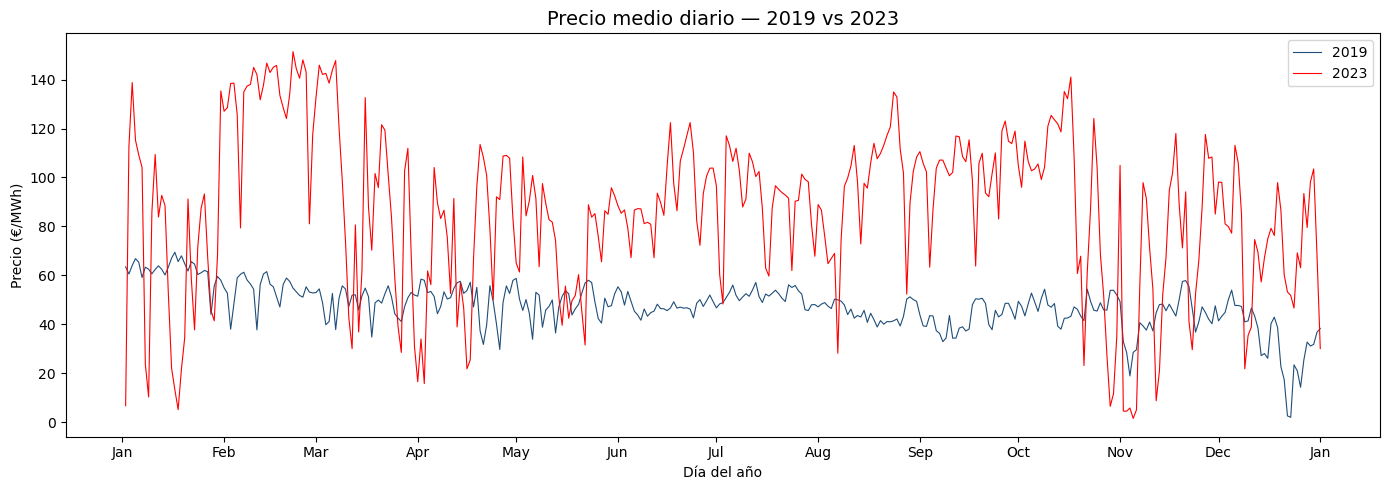

In [45]:
df_compare = pd.read_sql("""
    SELECT year, month, day, AVG(price_es) as avg_price
    FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    AND year IN (2019, 2023)
    GROUP BY year, month, day
    ORDER BY year, month, day
""", conn)

df_compare["date"] = pd.to_datetime(df_compare[["year", "month", "day"]])
df_2019 = df_compare[df_compare["year"] == 2019]
df_2023 = df_compare[df_compare["year"] == 2023]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_2019["date"].dt.dayofyear, df_2019["avg_price"], 
        label="2019", color="#1F4E79", linewidth=0.8)
ax.plot(df_2023["date"].dt.dayofyear, df_2023["avg_price"], 
        label="2023", color="red", linewidth=0.8)
ax.set_title("Precio medio diario — 2019 vs 2023", fontsize=14)
ax.set_xlabel("Día del año")
ax.set_ylabel("Precio (€/MWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/precio_diario_2019_vs_2023.png", dpi=150)
plt.show()

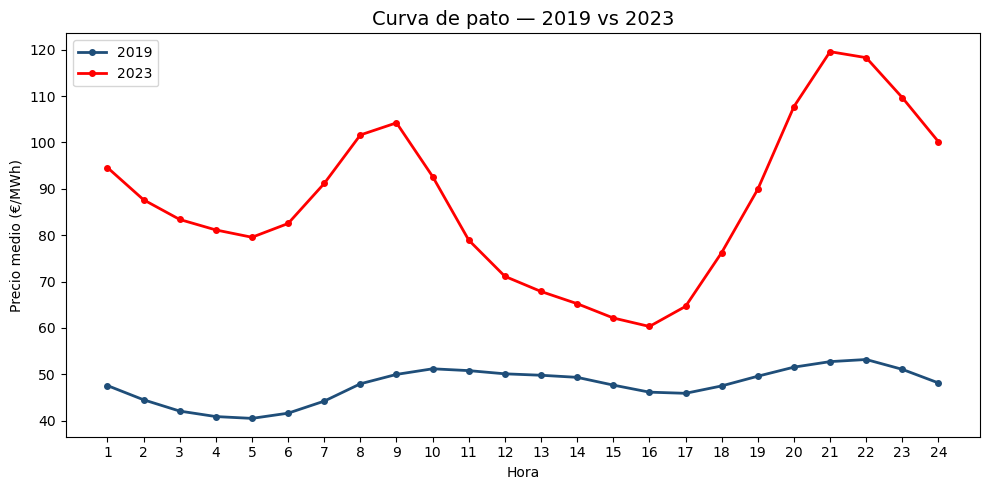

In [46]:
df_pato = pd.read_sql("""
    SELECT year, hour, AVG(price_es) as avg_price
    FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    AND year IN (2019, 2023)
    GROUP BY year, hour
    ORDER BY year, hour
""", conn)

df_pato_2019 = df_pato[df_pato["year"] == 2019]
df_pato_2023 = df_pato[df_pato["year"] == 2023]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_pato_2019["hour"], df_pato_2019["avg_price"],
        label="2019", color="#1F4E79", linewidth=2, marker="o", markersize=4)
ax.plot(df_pato_2023["hour"], df_pato_2023["avg_price"],
        label="2023", color="red", linewidth=2, marker="o", markersize=4)
ax.set_title("Curva de pato — 2019 vs 2023", fontsize=14)
ax.set_xlabel("Hora")
ax.set_ylabel("Precio medio (€/MWh)")
ax.set_xticks(range(1, 25))
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/curva_pato_2019_vs_2023.png", dpi=150)
plt.show()

BINGO! La curva de pato (caída de precios al mediodía por generación solar) apenas existía en 2019 y es claramente visible en 2023, reflejando el crecimiento de la capacidad solar instalada en España y el desacoplamiento del precio del gas tras la Excepción Ibérica de 2022. Ya se intuia la enorme diferencia de volatilidad en el precio diario de cada año. Aunque el precio de 2023 es de media superior al de 2019, teniendo en cuenta una inflacion media de 2.5% anual (con la guerra de por medio), se podria incluso concluir que el precio 'real' medio de la electricidad ha incluso bajado. No son solo picos

In [47]:
df_weekday = pd.read_sql("""
    SELECT 
        CAST(strftime('%w', datetime) AS INTEGER) as weekday,
        AVG(price_es) as avg_price
    FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    GROUP BY weekday
    ORDER BY weekday
""", conn)

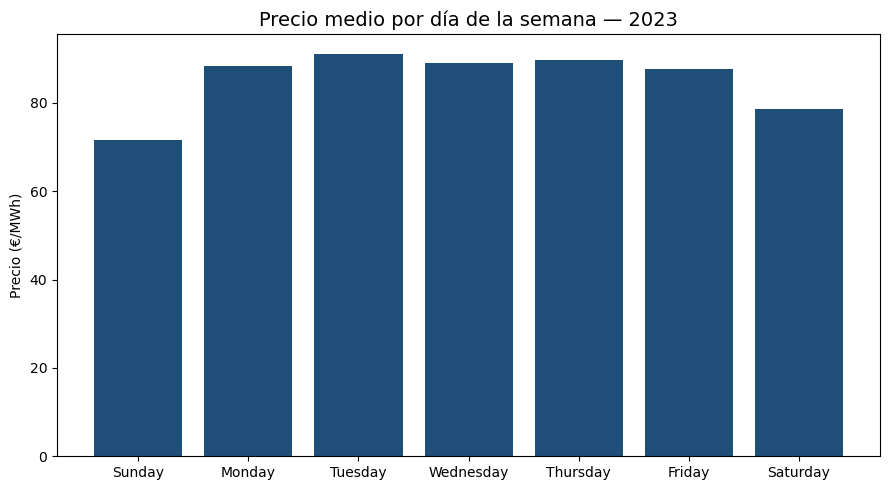

In [48]:
weekday_names = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
df_weekday["weekday_name"] = df_weekday["weekday"].map(lambda x: weekday_names[x])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(df_weekday["weekday_name"], df_weekday["avg_price"], color="#1F4E79")
ax.set_title("Precio medio por día de la semana — 2023", fontsize=14)
ax.set_ylabel("Precio (€/MWh)")
plt.tight_layout()
plt.savefig("../outputs/precio_por_dia_semana_2023.png", dpi=150)
plt.show()

Sí, fines de semana siempre menos demanda

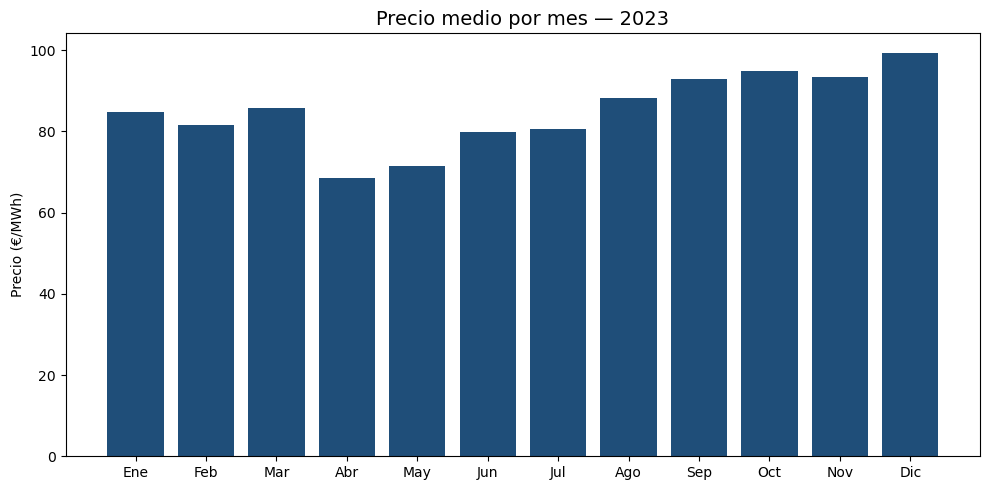

In [50]:
df_monthly = pd.read_sql("""
    SELECT month, AVG(price_es) as avg_price
    FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    GROUP BY month
    ORDER BY month
""", conn)

month_names = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", 
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
df_monthly["month_name"] = df_monthly["month"].astype('int').map(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_monthly["month_name"], df_monthly["avg_price"], color="#1F4E79")
ax.set_title("Precio medio por mes — 2023", fontsize=14)
ax.set_ylabel("Precio (€/MWh)")
plt.tight_layout()
plt.savefig("../outputs/precio_por_mes_2023.png", dpi=150)
plt.show()

Ahora no pega ese subidon de febrero. Quizas en 2023 fue raro...

### Outliers

In [53]:
pd.read_sql("""
    SELECT *
    FROM omie_prices_historic
    WHERE price_es <= 0
    AND hour BETWEEN 1 AND 24
    ORDER BY price_es
""", conn)

,hour,price_es,year,month,day,datetime
0,12,-2.0,2024,6,16,2024-06-16 11:00:00
1,13,-2.0,2024,6,16,2024-06-16 12:00:00
2,14,-2.0,2024,6,16,2024-06-16 13:00:00
3,15,-2.0,2024,6,16,2024-06-16 14:00:00
4,16,-2.0,2024,6,16,2024-06-16 15:00:00
...,...,...,...,...,...,...
891,16,0.0,2024,10,8,2024-10-08 15:00:00
892,15,0.0,2024,10,13,2024-10-13 14:00:00
893,16,0.0,2024,10,13,2024-10-13 15:00:00
894,13,0.0,2024,10,20,2024-10-20 12:00:00


Ahora también hay precios negativos. Sobreproducción de renovables que el mercado no absorbe

In [55]:
pd.read_sql("""
    SELECT year, month, day, hour, price_es
    FROM omie_prices_historic
    WHERE price_es > 500
    AND hour BETWEEN 1 AND 24
    ORDER BY price_es DESC
""", conn)

,year,month,day,hour,price_es
0,2022,3,8,20,700.00
1,2022,3,8,21,654.91
2,2022,3,8,19,651.00
3,2022,3,8,22,651.00
4,2022,3,8,23,650.00
5,2022,3,8,9,645.00
6,2022,3,9,20,605.00
7,2022,3,8,18,603.08
8,2022,3,8,10,601.00
9,2022,3,8,8,600.00


Precios disparados de la crisis energetica de 2022

In [ ]:
conn.close()

: 